In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # para hacer los gráficos
import seaborn as sns           # para gráficos
%matplotlib inline
# %matplotlib inline  : para que cuando veamos la presentacion se vea dentro del notebook y no en otra ventana

In [2]:
data = pd.read_excel('/content/drive/MyDrive/titanic.xlsx' )

**ANÁLISIS**

In [3]:
data.head() #para leer rapidamente los datos

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Podemos ver a simple vista, la clase de los pasajeros, si sobrevivieron o no. Los nombres de los pasajeros, el sexo, edad, el número de hermanos/conyuges a bordo. También tenemos el número de padres/niños a bordo, el ticket del pasaje, el precio, la cabina donde se encontraban, el puerto de embarque donde C = Cherburgo, Q = Queenstown, S = Southampton. Además nos muestra el bote salvavidas (si subio) y el número de cuerpo (si no sobrevivió y el cuerpo fue recuperado)

Las variables como ser 'nombre' la voy a eliminar ya que es muy específica (única) y no influiria en nada para mi estudio para saber quien sobreviria y quien no.
Lo mismo para el caso del precio del ticket, si bien me servirá para saber en que parte estuvo ubicado el pasajero, pero eso lo puedo ver también con la clase, si estuvo en 1ra, 2da o 3er clase. También lo mismo con el nombre o código del ticket. La columna 'body' tambien podriamos eliminarla ya que no impactaria (si se recupero el cuerpo) en cierta forma sobre nuestro análisis.

In [4]:
data.drop(["name", "ticket", "fare", "body"], axis = 1, inplace = True)  #inplace true es para que se guarden los cambios en memoria
data.head()

,pclass,survived,sex,age,sibsp,parch,cabin,embarked,boat,home.dest
0,1,1,female,29.0000,0,0,B5,S,2,"St Louis, MO"
1,1,1,male,0.9167,1,2,C22 C26,S,11,"Montreal, PQ / Chesterville, ON"
2,1,0,female,2.0000,1,2,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,male,30.0000,1,2,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"
4,1,0,female,25.0000,1,2,C22 C26,S,NaN,"Montreal, PQ / Chesterville, ON"


Realizamos un primer análisis para observar ciertas medidas estadísticas de como se comportan las diferentes variables:

In [5]:
data.describe()

,pclass,survived,age,sibsp,parch
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027
std,0.837836,0.486055,14.413500,1.041658,0.865560
min,1.000000,0.000000,0.166700,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000


Acá por ejemplo podemos ver en edad, que uno tiene un valor de 0.16, podria ser raro, pero tambien se puede considerar que es un bebé. Podemos observar también valores como el promedio, el minímo y el máximo, entre otros.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   sex        1309 non-null   object 
 3   age        1046 non-null   float64
 4   sibsp      1309 non-null   int64  
 5   parch      1309 non-null   int64  
 6   cabin      295 non-null    object 
 7   embarked   1307 non-null   object 
 8   boat       486 non-null    object 
 9   home.dest  745 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 102.4+ KB


Acá podemos observar que tenemos datos faltantes en algunas columnas. Tenemos un total de 1309 datos, de las cuales en la columna como ser 'edad' cuenta con 1046 del total de datos, con lo cual no es mucho los faltantes. La columna 'cabina' con 295, esta si representa una gran falta de valores, con lo cual no es muy recomendable completarla, sino que capaz lo más óptimo sea eliminarla. La de  'embarque' cuenta con 1307 que no es tanto, solo le faltarian dos valores y después tenemos la columna 'boat' con 486 y 'home.dest' con 745.

In [7]:
#Entonces decidimos eliminar la columna 'cabin'. Además eliminamos 'home.dest' más que nada porque no seria muy relevante el destino al cual llegarían los pasajeros.
#Con respecto a 'boat' podriamos también sacarla ya que llegamos a la conclusión que la mayoría que se subió al bote salvavidas, sobrevivió. Además estas dos variables
# (boat y survived) cualquiera de las dos me explican lo que busco predecir, ya que si se subio al bote es muy probable que haya sobrevivido. Por lo tanto, elijo trabajar con "survived"
data.drop(["cabin", "boat", "home.dest"], axis = 1, inplace = True)
data

,pclass,survived,sex,age,sibsp,parch,embarked
0,1,1,female,29.0000,0,0,S
1,1,1,male,0.9167,1,2,S
2,1,0,female,2.0000,1,2,S
3,1,0,male,30.0000,1,2,S
4,1,0,female,25.0000,1,2,S
...,...,...,...,...,...,...,...
1304,3,0,female,14.5000,1,0,C
1305,3,0,female,NaN,1,0,C
1306,3,0,male,26.5000,0,0,C
1307,3,0,male,27.0000,0,0,C


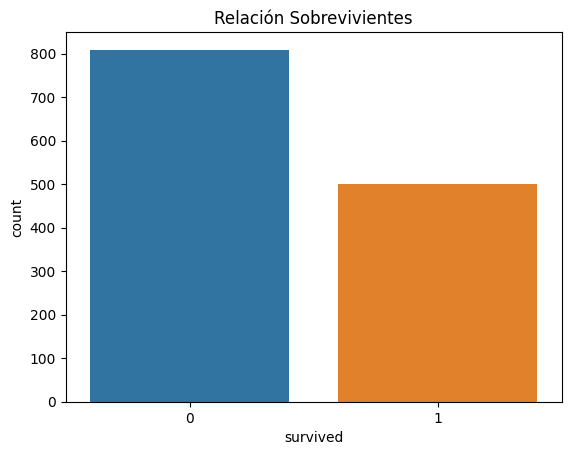

In [8]:
plt.title("Relación Sobrevivientes")
sns.countplot(x = "survived", data = data);

In [9]:
data.survived.value_counts()

0    809
1    500
Name: survived, dtype: int64

Acá se puede observar la diferencia entre los que sobrevivieron de los que no es de 309, con lo cual se podría decir que la relación no es demasiado grande.

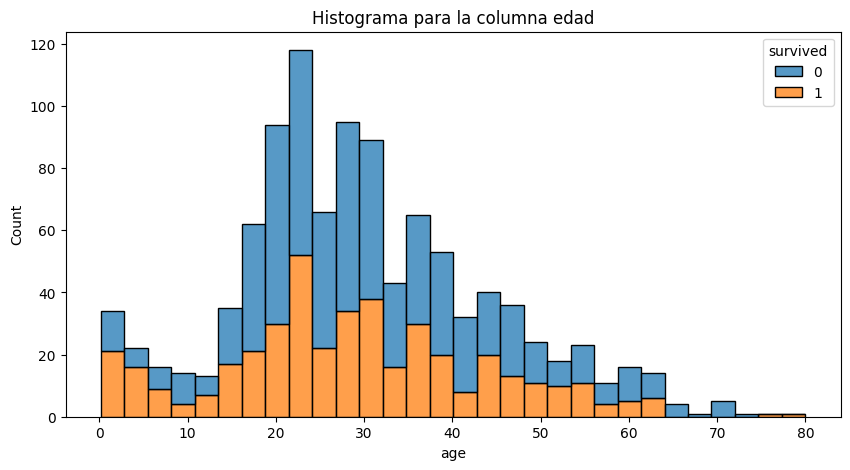

In [10]:
#Bueno ahora quisiera ver el comportamiento de mi variable objetivo en relacion a las demás variables. En este caso analizamos como se comporta la varible 'survived' en relación a 'age'
plt.figure(figsize = (10,5))
plt.title("Histograma para la columna edad")
sns.histplot(data = data, x = 'age', bins = 30, hue = "survived", multiple = "stack");

Podemos observar con esta relación, que el número de sobrevivientes en edades mas pequeñas (de 0 a 10, de 20 a 30 por ej) es mayor a la tasa de sobreviventes que de edad más adulta (60 - 70). Esto se puede llegar a explicar, ya que en ese momento, se habia decidido que quienes tenían prioridad para subir a los botes salvavidas eran mujeres y niños.
Entonces podemos agregar que  a medida que aumente el rango de edad, menor eran las propabilidades de que sobrevivieran.

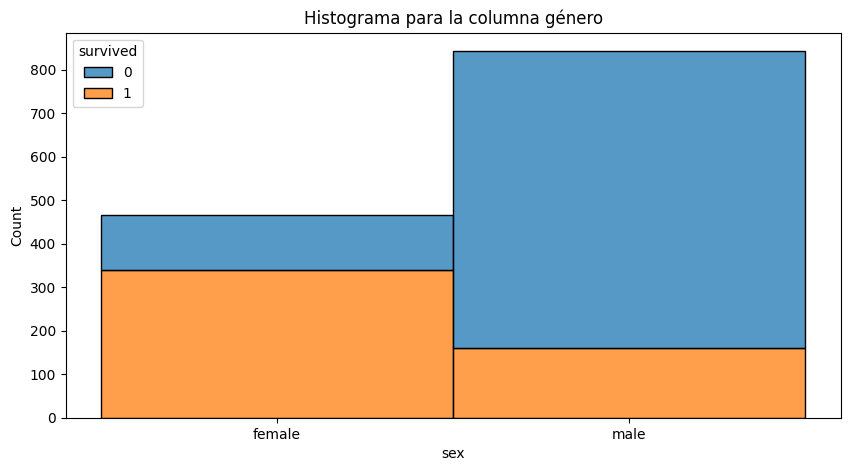

In [11]:
#Bueno ahora quisiera ver el comportamiento de mi variable objetivo en relacion a  la variable 'sex'
plt.figure(figsize = (10,5))
plt.title("Histograma para la columna género")
sns.histplot(data = data, x = 'sex', bins = 30, hue = "survived", multiple = "stack");

Esto comprueba también a simple vista, que las mujeres por la prioridad que tenian de subirse a los botes, junto con los niños, tuvieron más probabilidades de salvarse.

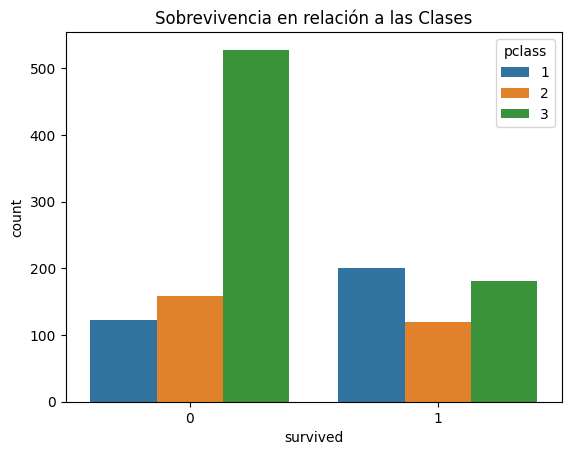

In [12]:
#Bueno ahora analizamos en relación a las clases
plt.title("Sobrevivencia en relación a las Clases")
sns.countplot(x = "survived", data = data, hue = 'pclass');

Acá podemos ver las diferentes clases, tenemos 1ra clase, 2da clase y 3ra clase. De estas tres, la 3ra es la que cuenta con un mayor número de personas que no sobrevivieron. Esto capaz se deba a que los de esta clase, se encontraban en niveles del barco más bajos, dificultandoles así la salida para poder llegar a los botes salvavidas.
Sin embargo, si lo vemos desde el punto de los que  sobrevivieron, no hay una gran variedad en cuanto a las clases de pasajeros, es decir, que la supervivencia está un poco independiente en relación a las clases.
Por ello, vamos analizar la distribución de los datos en relación a las clases, para verlo en más detalle

In [13]:
data.pclass.value_counts()

3    709
1    323
2    277
Name: pclass, dtype: int64

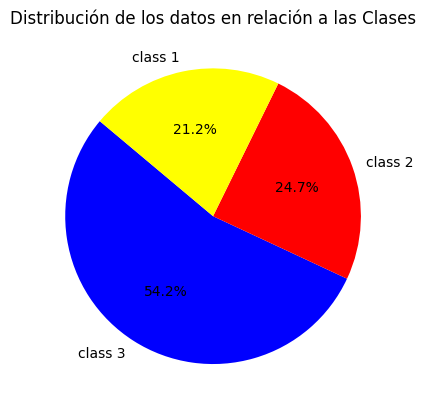

In [14]:
plt.title("Distribución de los datos en relación a las Clases")
plt.pie( data.pclass.value_counts().values, labels = ["class 3", "class 2", "class 1"], colors = ["blue", "red", "yellow"], autopct='%.1f%%', startangle = 140);

Podemos ver que de la totalidad de pasajeros, el 54.2 % correspondia a la clase 3, es decir más de la mitad. Con lo cual, podemos constatar que claramente la mayoria de las personas que no sobrevivieron iban a  pertenecer a esta clase, si representan a más del 50% del total. Por ello, es obvio que la mayoria que no sobrevivio es de clase 3, ya que representan la mayor cantidad de pasajeros dentro del bote también.

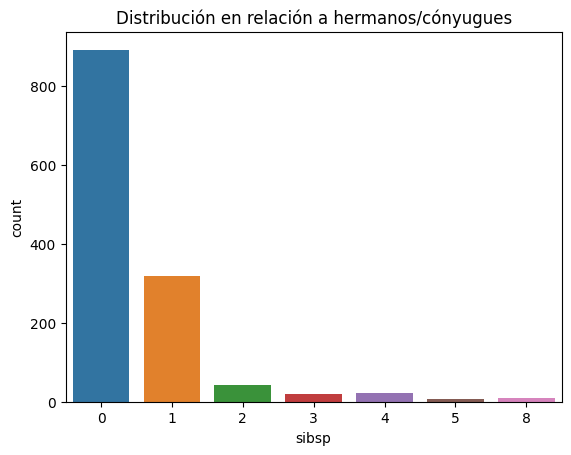

In [15]:
plt.title("Distribución en relación a hermanos/cónyugues")
sns.countplot(x = "sibsp", data = data);

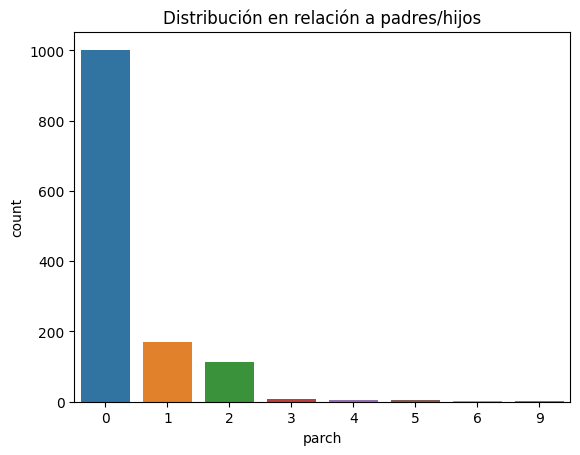

In [16]:
plt.title("Distribución en relación a padres/hijos")
sns.countplot(x = "parch", data = data);

Con estas dos variables podriamos decir que son más del tipo categóricas, donde muestran si padres por ej tienen hijos o no, también si los que eran conyugues estaban acompañados de más familiares o no. A primera vista no se si seria de gran  importancia la variable sibsp, más que nada la distribución y tasa de supervivencia entre las diferentes categorías. Además tiene más relevancia y es más explicativa la variable parch por la relación de padres e hijos. Con lo cual decidimos eliminar a sibsp.

In [17]:
data.drop(["sibsp"], axis = 1, inplace = True)  #inplace true es para que se guarden los cambios en memoria
data.head()

,pclass,survived,sex,age,parch,embarked
0,1,1,female,29.0000,0,S
1,1,1,male,0.9167,2,S
2,1,0,female,2.0000,2,S
3,1,0,male,30.0000,2,S
4,1,0,female,25.0000,2,S


**PREPARACIÓN DE LOS DATOS**

Completar datos faltantes.
En este caso vamos a completar la variable 'edad' para rellenar los valores faltantes. Para ello, usaremos el promedio como método.

In [18]:
data.age.mean()

29.8811345124283

In [19]:
data['age'].fillna(data.age.mean(), inplace = True)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   parch     1309 non-null   int64  
 5   embarked  1307 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 61.5+ KB


Como podemos ver la columna 'edad' ya está completada con todos los valores. Ahora quedaria 'embarque' que tiene dos valores faltantes, podriamos para ello completarla o bien podriamos borrar esas dos filas ya que no son muchas.

In [21]:
data.dropna(inplace = True)

In [22]:
data.info()
#Como podemos ver terminamos eliminando esas dos filas que le faltaban los valores a embarque

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1307 entries, 0 to 1308
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1307 non-null   int64  
 1   survived  1307 non-null   int64  
 2   sex       1307 non-null   object 
 3   age       1307 non-null   float64
 4   parch     1307 non-null   int64  
 5   embarked  1307 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 71.5+ KB


In [23]:
data.head()

,pclass,survived,sex,age,parch,embarked
0,1,1,female,29.0000,0,S
1,1,1,male,0.9167,2,S
2,1,0,female,2.0000,2,S
3,1,0,male,30.0000,2,S
4,1,0,female,25.0000,2,S


**CONVERTIR VARIABLES CATEGÓRICAS A NUMÉRICAS**

In [24]:
#Convierto en ceros y uno la columna género
data['masculino'] = (data['sex'] == 'male').astype(int)
data['femenino'] = (data['sex'] == 'female').astype(int)

print(data)

      pclass  survived     sex        age  parch embarked  masculino  femenino
0          1         1  female  29.000000      0        S          0         1
1          1         1    male   0.916700      2        S          1         0
2          1         0  female   2.000000      2        S          0         1
3          1         0    male  30.000000      2        S          1         0
4          1         0  female  25.000000      2        S          0         1
...      ...       ...     ...        ...    ...      ...        ...       ...
1304       3         0  female  14.500000      0        C          0         1
1305       3         0  female  29.881135      0        C          0         1
1306       3         0    male  26.500000      0        C          1         0
1307       3         0    male  27.000000      0        C          1         0
1308       3         0    male  29.000000      0        S          1         0

[1307 rows x 8 columns]


In [25]:
#Elimino la variable original
data.drop([	'sex'], axis = 1, inplace = True)
data

,pclass,survived,age,parch,embarked,masculino,femenino
0,1,1,29.000000,0,S,0,1
1,1,1,0.916700,2,S,1,0
2,1,0,2.000000,2,S,0,1
3,1,0,30.000000,2,S,1,0
4,1,0,25.000000,2,S,0,1
...,...,...,...,...,...,...,...
1304,3,0,14.500000,0,C,0,1
1305,3,0,29.881135,0,C,0,1
1306,3,0,26.500000,0,C,1,0
1307,3,0,27.000000,0,C,1,0


Aclaración: la única variable que no se toca es la 'survived' porque es mi target, mi variable a predecir. Y en este caso 'age' no la modificamos porque ya es una variable numérica

In [26]:
data.head()

,pclass,survived,age,parch,embarked,masculino,femenino
0,1,1,29.0000,0,S,0,1
1,1,1,0.9167,2,S,1,0
2,1,0,2.0000,2,S,0,1
3,1,0,30.0000,2,S,1,0
4,1,0,25.0000,2,S,0,1


In [27]:
#Convierto en ceros y uno la columna embarque
data['S'] = (data['embarked'] == 'S').astype(int)
data['C'] = (data['embarked'] == 'C').astype(int)
data['Q'] = (data['embarked'] == 'Q').astype(int)

print(data)

      pclass  survived        age  parch embarked  masculino  femenino  S  C  \
0          1         1  29.000000      0        S          0         1  1  0   
1          1         1   0.916700      2        S          1         0  1  0   
2          1         0   2.000000      2        S          0         1  1  0   
3          1         0  30.000000      2        S          1         0  1  0   
4          1         0  25.000000      2        S          0         1  1  0   
...      ...       ...        ...    ...      ...        ...       ... .. ..   
1304       3         0  14.500000      0        C          0         1  0  1   
1305       3         0  29.881135      0        C          0         1  0  1   
1306       3         0  26.500000      0        C          1         0  0  1   
1307       3         0  27.000000      0        C          1         0  0  1   
1308       3         0  29.000000      0        S          1         0  1  0   

      Q  
0     0  
1     0  
2     0  

In [28]:
#Elimino la variable original
data.drop(['embarked'], axis = 1, inplace = True)

In [29]:
data.head()

,pclass,survived,age,parch,masculino,femenino,S,C,Q
0,1,1,29.0000,0,0,1,1,0,0
1,1,1,0.9167,2,1,0,1,0,0
2,1,0,2.0000,2,0,1,1,0,0
3,1,0,30.0000,2,1,0,1,0,0
4,1,0,25.0000,2,0,1,1,0,0


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1307 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1307 non-null   int64  
 1   survived   1307 non-null   int64  
 2   age        1307 non-null   float64
 3   parch      1307 non-null   int64  
 4   masculino  1307 non-null   int64  
 5   femenino   1307 non-null   int64  
 6   S          1307 non-null   int64  
 7   C          1307 non-null   int64  
 8   Q          1307 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 102.1 KB


**CONSTRUCCIÓN DEL MODELO**

In [31]:
data.head()

,pclass,survived,age,parch,masculino,femenino,S,C,Q
0,1,1,29.0000,0,0,1,1,0,0
1,1,1,0.9167,2,1,0,1,0,0
2,1,0,2.0000,2,0,1,1,0,0
3,1,0,30.0000,2,1,0,1,0,0
4,1,0,25.0000,2,0,1,1,0,0


In [32]:
y = data['survived']
x = data.drop(['survived'], axis = 1)

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=123)
x_val_train, x_val_test, y_val_train, y_val_test = train_test_split(x_train, y_train, test_size=0.20, random_state=123)

**ENTRENAMIENTO**

Búsqueda del mejor modelo

In [34]:
#Modelo 1
from sklearn.linear_model import LogisticRegression
reg_log = LogisticRegression(random_state=123)
reg_log.fit(x_val_train, y_val_train)

y_val_pred_reg = reg_log.predict(x_val_test)

from sklearn.metrics import accuracy_score
acc_reg_log = accuracy_score(y_val_test, y_val_pred_reg)
acc_reg_log

0.7703349282296651

In [35]:
#Modelo 2
numero_estimadores = (50, 100, 150)
profundidad_maxima = (2, 4, 6)
for i in numero_estimadores:
  for j in profundidad_maxima:
     from sklearn.ensemble import RandomForestClassifier
     random_forest = RandomForestClassifier( n_estimators = i, max_depth= j ,random_state=123)
     random_forest.fit(x_val_train, y_val_train)
     y_val_pred_random = random_forest.predict(x_val_test)

     acc_random = accuracy_score(y_val_test, y_val_pred_random)
     acc_random

     print('Estimador:', i, 'Profundidad', j , 'acc:',  acc_random)

Estimador: 50 Profundidad 2 acc: 0.7799043062200957
Estimador: 50 Profundidad 4 acc: 0.8133971291866029
Estimador: 50 Profundidad 6 acc: 0.8133971291866029
Estimador: 100 Profundidad 2 acc: 0.7751196172248804
Estimador: 100 Profundidad 4 acc: 0.8133971291866029
Estimador: 100 Profundidad 6 acc: 0.8133971291866029
Estimador: 150 Profundidad 2 acc: 0.7751196172248804
Estimador: 150 Profundidad 4 acc: 0.8181818181818182
Estimador: 150 Profundidad 6 acc: 0.8181818181818182


In [36]:
pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 2.2 MB/s eta 0:00:00


In [37]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



prof = (16, 10, 8, 5)
AT = (0.04, 0.1, 0.2, 0.4)
IT = (50, 25, 10, 8, 5)

for a in prof:
    for b in AT:
        for c in IT:
            cat_boost = CatBoostClassifier(iterations=c, depth=a, learning_rate=b, loss_function='MultiClass', cat_features=[], random_state=123, verbose=0)
            cat_boost.fit(x_val_train, y_val_train)
            y_val_pred_cat = cat_boost.predict(x_val_test)
            acc_catboost = accuracy_score(y_val_test, y_val_pred_cat)
            acc_catboost

            print('AT:', b, 'IT', c , 'Profundidad:', a, 'Acc:', acc_catboost)

AT: 0.04 IT 50 Profundidad: 16 Acc: 0.8086124401913876
AT: 0.04 IT 25 Profundidad: 16 Acc: 0.8133971291866029
AT: 0.04 IT 10 Profundidad: 16 Acc: 0.8133971291866029
AT: 0.04 IT 8 Profundidad: 16 Acc: 0.8133971291866029
AT: 0.04 IT 5 Profundidad: 16 Acc: 0.8133971291866029
AT: 0.1 IT 50 Profundidad: 16 Acc: 0.8086124401913876
AT: 0.1 IT 25 Profundidad: 16 Acc: 0.8086124401913876
AT: 0.1 IT 10 Profundidad: 16 Acc: 0.8229665071770335
AT: 0.1 IT 8 Profundidad: 16 Acc: 0.8229665071770335
AT: 0.1 IT 5 Profundidad: 16 Acc: 0.8229665071770335
AT: 0.2 IT 50 Profundidad: 16 Acc: 0.7894736842105263
AT: 0.2 IT 25 Profundidad: 16 Acc: 0.7942583732057417
AT: 0.2 IT 10 Profundidad: 16 Acc: 0.7942583732057417
AT: 0.2 IT 8 Profundidad: 16 Acc: 0.8133971291866029
AT: 0.2 IT 5 Profundidad: 16 Acc: 0.8133971291866029
AT: 0.4 IT 50 Profundidad: 16 Acc: 0.7607655502392344
AT: 0.4 IT 25 Profundidad: 16 Acc: 0.7799043062200957
AT: 0.4 IT 10 Profundidad: 16 Acc: 0.8086124401913876
AT: 0.4 IT 8 Profundidad: 16 

EVALÚO MI MEJOR MODELO

In [38]:
catb_mejor_modelo = CatBoostClassifier(iterations=8, depth=8, learning_rate=0.1, loss_function='MultiClass', cat_features=[], random_state=123, verbose=0)
catb_mejor_modelo.fit(x_train, y_train)
y_pred_catb_mejor = catb_mejor_modelo.predict(x_test)

acc_catb_mejor = accuracy_score(y_test, y_pred_catb_mejor)
acc_catb_mejor

0.8015267175572519

PONGO EN PRODUCCIÒN MI MODELO

In [39]:
modelo_prod = CatBoostClassifier(iterations=8, depth=8, learning_rate=0.1, loss_function='MultiClass', cat_features=[], random_state=123, verbose=0)
modelo_prod.fit(x, y)

**ANÁLISIS DE RENDIMIENTO DEL MODELO**

Para este análisis usaremos dos medidas: Matriz de confusión y el Informe de clasificación con precisión, recuperación y puntuación F1.
La matriz de confusión es una tabla que muestra el número de predicciones correctas e incorrectas en un problema de clasificación cuando se conocen los valores reales del conjunto de prueba. Tiene el siguiente formato:

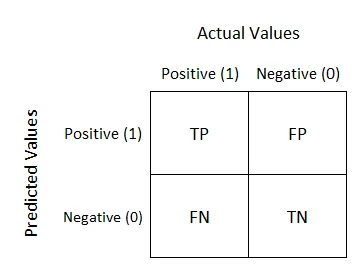





Matriz de Confusión:
[[141  11]
 [ 41  69]]


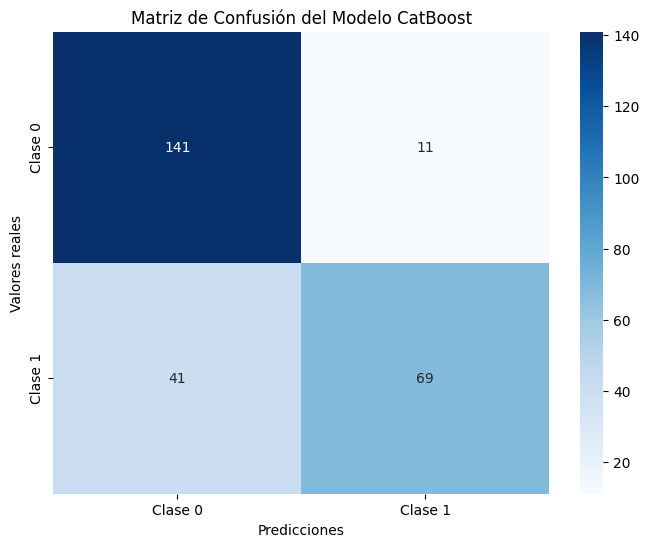

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.93      0.84       152
           1       0.86      0.63      0.73       110

    accuracy                           0.80       262
   macro avg       0.82      0.78      0.79       262
weighted avg       0.81      0.80      0.79       262



In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Calcular la matriz de confusión
conf_matrix_catb_mejor = confusion_matrix(y_test, y_pred_catb_mejor)

# Imprimir la matriz de confusión
print("Matriz de Confusión:")
print(conf_matrix_catb_mejor)


# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_catb_mejor, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión del Modelo CatBoost')
plt.show()


# Generar el informe de clasificación
classificationReport_catb_mejor = classification_report(y_test, y_pred_catb_mejor)

# Imprimir el informe de clasificación
print("Informe de Clasificación:")
print(classificationReport_catb_mejor)


**CURVA DE APRENDIZAJE**

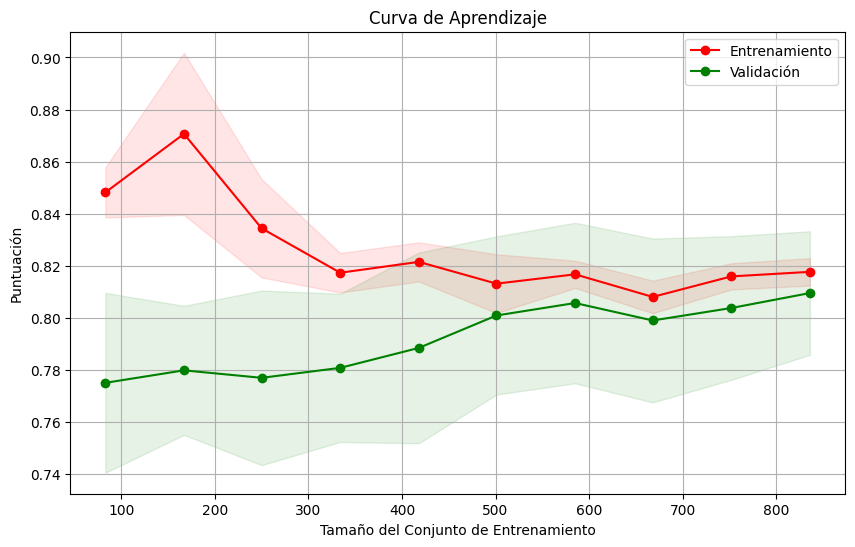

In [41]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Definir el modelo con los hiperparámetros seleccionados
catb_mejor_modelo = CatBoostClassifier(iterations=8, depth=8, learning_rate=0.1, loss_function='MultiClass', cat_features=[], random_state=123, verbose=0)

# Generar la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(catb_mejor_modelo, x_train, y_train, cv=5,
                                                        train_sizes=np.linspace(0.1, 1.0, 10))


# Calcular los promedios y desviaciones estándar
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Graficar la curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje")
plt.xlabel("Tamaño del Conjunto de Entrenamiento")
plt.ylabel("Puntuación")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std,
                 alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std,
                 alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validación")

plt.legend(loc="best")
plt.show()